In [30]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

import pickle

In [31]:
df = pd.read_csv('student_mental_health_burnout.csv')
df.head()

,student_id,age,gender,course,year,daily_study_hours,daily_sleep_hours,screen_time_hours,stress_level,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,sleep_quality,attendance_percentage,cgpa,internet_quality,burnout_level
0,100001,23,Male,BTech,1st,4.3,6.8,6.1,High,10,3,4,2,6,1.8,Average,66.5,9.63,Good,High
1,100002,20,Male,BTech,3rd,1.4,4.7,3.0,High,2,10,8,5,9,1.9,Poor,55.8,6.04,Poor,Low
2,100003,24,Female,BCA,4th,3.7,4.8,1.5,Low,2,7,8,6,3,0.8,Good,85.0,8.31,Good,High
3,100004,21,Male,BSc,4th,1.6,6.7,7.0,High,3,3,4,9,9,0.7,Poor,89.1,5.95,Good,High
4,100005,23,Other,BSc,4th,2.0,6.7,5.4,High,7,7,6,4,4,1.7,Good,58.7,8.51,Good,Low


In [32]:
# Basic info about dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 20 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   student_id               150000 non-null  int64  
 1   age                      150000 non-null  int64  
 2   gender                   150000 non-null  object 
 3   course                   150000 non-null  object 
 4   year                     150000 non-null  object 
 5   daily_study_hours        150000 non-null  float64
 6   daily_sleep_hours        150000 non-null  float64
 7   screen_time_hours        150000 non-null  float64
 8   stress_level             150000 non-null  object 
 9   anxiety_score            150000 non-null  int64  
 10  depression_score         150000 non-null  int64  
 11  academic_pressure_score  150000 non-null  int64  
 12  financial_stress_score   150000 non-null  int64  
 13  social_support_score     150000 non-null  int64  
 14  phys

In [33]:
#Missing vales:
df.isnull().sum()

,0
student_id,0
age,0
gender,0
course,0
year,0
daily_study_hours,0
daily_sleep_hours,0
screen_time_hours,0
stress_level,0
anxiety_score,0


In [34]:
print("Duplicate Vales: ", df.duplicated().sum())

Duplicate Vales:  0


In [35]:
df.describe()

,student_id,age,daily_study_hours,daily_sleep_hours,screen_time_hours,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,attendance_percentage,cgpa
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000
mean,175000.500000,21.000380,5.507869,6.499361,6.502819,5.493907,5.497360,5.507427,5.496027,5.516060,0.998115,75.009528,6.997389
std,43301.414527,2.581216,2.595592,1.443859,3.178948,2.872607,2.869022,2.875524,2.864698,2.870493,0.578866,14.409510,1.732180
min,100001.000000,17.000000,1.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,50.000000,4.000000
25%,137500.750000,19.000000,3.300000,5.200000,3.700000,3.000000,3.000000,3.000000,3.000000,3.000000,0.500000,62.500000,5.500000
50%,175000.500000,21.000000,5.500000,6.500000,6.500000,5.000000,5.000000,6.000000,6.000000,6.000000,1.000000,75.000000,6.990000
75%,212500.250000,23.000000,7.700000,7.700000,9.300000,8.000000,8.000000,8.000000,8.000000,8.000000,1.500000,87.500000,8.500000
max,250000.000000,25.000000,10.000000,9.000000,12.000000,10.000000,10.000000,10.000000,10.000000,10.000000,2.000000,100.000000,10.000000


In [36]:
print("Columns: ", df.columns)

Columns:  Index(['student_id', 'age', 'gender', 'course', 'year', 'daily_study_hours',
       'daily_sleep_hours', 'screen_time_hours', 'stress_level',
       'anxiety_score', 'depression_score', 'academic_pressure_score',
       'financial_stress_score', 'social_support_score',
       'physical_activity_hours', 'sleep_quality', 'attendance_percentage',
       'cgpa', 'internet_quality', 'burnout_level'],
      dtype='object')


In [37]:
print("Shape:", df.shape)

Shape: (150000, 20)


EDA (Exploratory Data Analysis)

In [38]:
# Count of burnout levels
df['burnout_level'].value_counts()

,count
burnout_level,
Low,50265
Medium,49969
High,49766


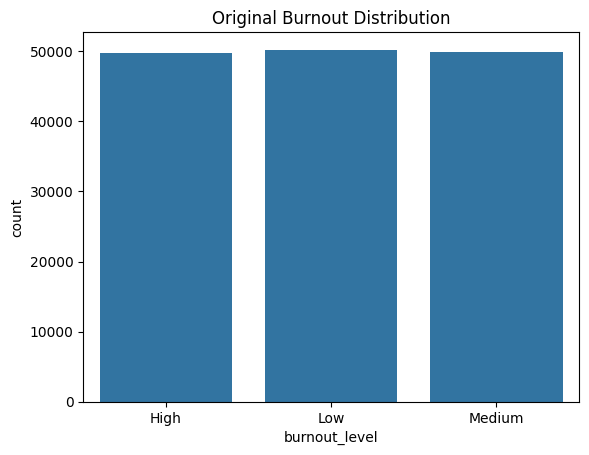

In [39]:
# Burnout distribution (old target)
sns.countplot(x='burnout_level', data=df)
plt.title("Original Burnout Distribution")
plt.show()

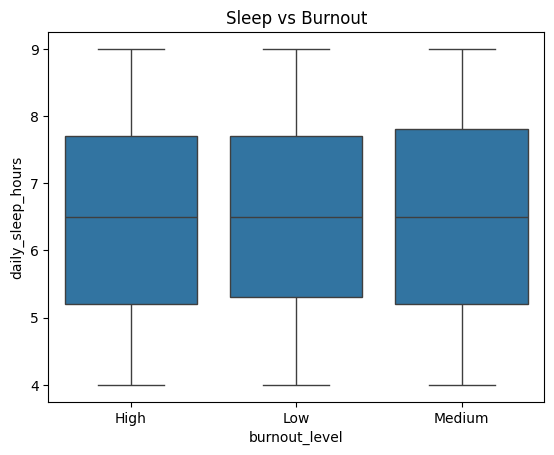

In [40]:
# Sleep vs burnout
sns.boxplot(x='burnout_level', y='daily_sleep_hours', data=df)
plt.title("Sleep vs Burnout")
plt.show()

Data Preprocessing

In [42]:
df = df.drop('student_id', axis=1)

In [43]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = df.select_dtypes(include='object').columns

print("Categorical columns:", categorical_cols)

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

Categorical columns: Index(['gender', 'course', 'year', 'stress_level', 'sleep_quality',
       'internet_quality', 'burnout_level'],
      dtype='object')


In [44]:
df.head()

,age,gender,course,year,daily_study_hours,daily_sleep_hours,screen_time_hours,stress_level,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,sleep_quality,attendance_percentage,cgpa,internet_quality,burnout_level
0,23,1,3,0,4.3,6.8,6.1,0,10,3,4,2,6,1.8,0,66.5,9.63,1,0
1,20,1,3,2,1.4,4.7,3.0,0,2,10,8,5,9,1.9,2,55.8,6.04,2,1
2,24,0,1,3,3.7,4.8,1.5,1,2,7,8,6,3,0.8,1,85.0,8.31,1,0
3,21,1,2,3,1.6,6.7,7.0,0,3,3,4,9,9,0.7,2,89.1,5.95,1,0
4,23,2,2,3,2.0,6.7,5.4,0,7,7,6,4,4,1.7,1,58.7,8.51,1,1


In [45]:
# Create burnout score using features
df['burnout_level'] = (
    df['stress_level'] * 2
    + df['screen_time_hours']
    - df['daily_sleep_hours']
    - df['physical_activity_hours']
)

# Convert into 3 categories
df['burnout_level'] = pd.cut(
    df['burnout_level'],
    bins=3,
    labels=[0, 1, 2]
)

In [46]:
y = df['burnout_level']

X = df.drop('burnout_level', axis=1)

Feature Engineering

In [47]:
# Creating a new feature combining lifestyle factors
X['lifestyle_score'] = (
    df['daily_sleep_hours'] +
    df['physical_activity_hours'] -
    df['screen_time_hours']
)

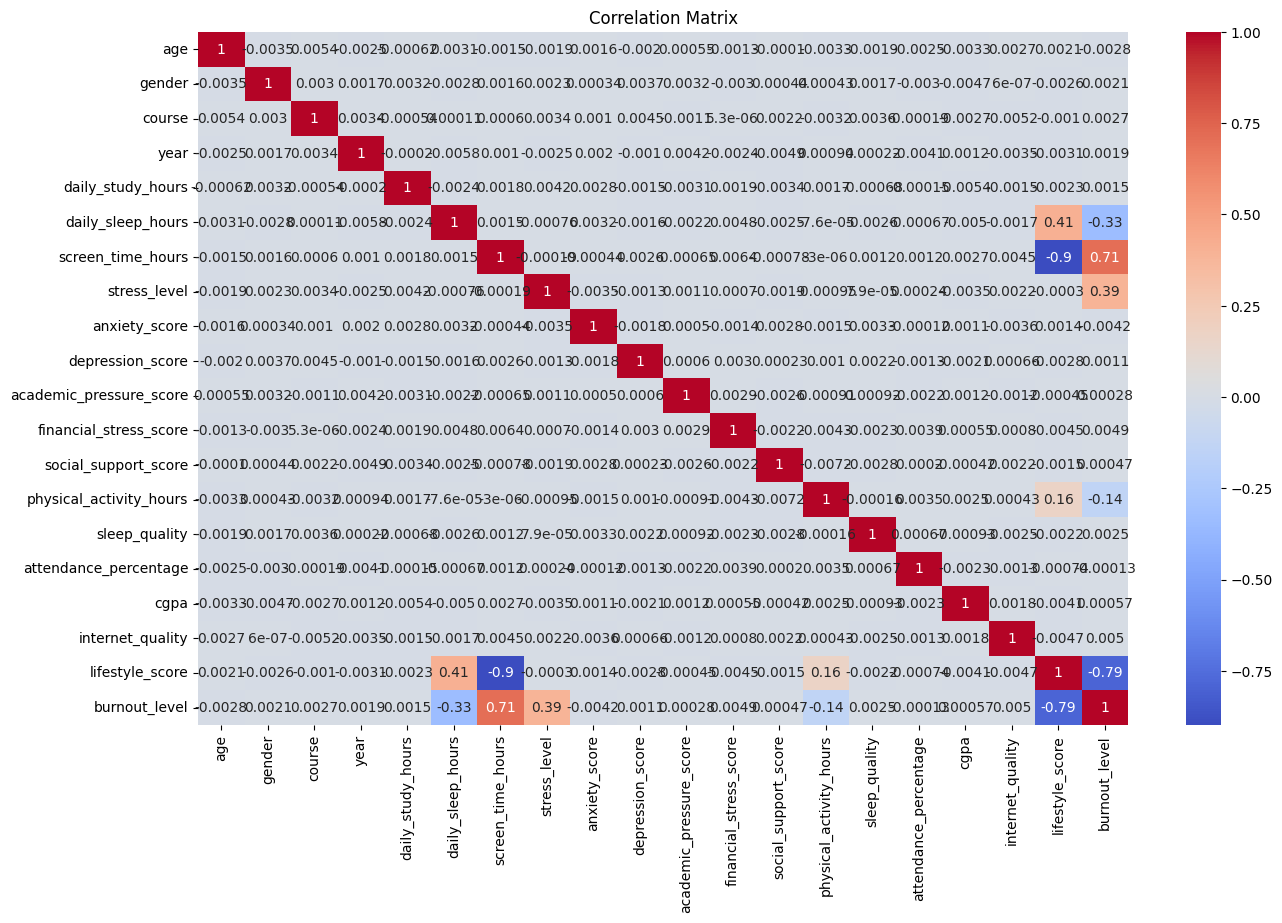

In [48]:
#Correlation Heatmap
temp_df = X.copy()
temp_df['burnout_level'] = y

plt.figure(figsize=(15,9))
sns.heatmap(temp_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [49]:
print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (150000, 19)
Target shape: (150000,)


Train Test Split

In [50]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Feature Scaling

In [51]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Model Training

In [52]:
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import VotingClassifier
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

In [53]:
#Smote
# Handle class imbalance
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

In [54]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(
        n_estimators=300,
        max_depth=15,
        random_state=42
    ),
    'SVM': SVC(),
    'KNN': KNeighborsClassifier(),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
}

In [55]:
voting_model = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(max_iter=1000)),
        ('rf', RandomForestClassifier(n_estimators=200)),
        ('xgb', XGBClassifier(use_label_encoder=False, eval_metric='mlogloss'))
    ],
    voting='hard'
)

models['Voting (Hybrid)'] = voting_model

In [56]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results.append([name, acc])

results_df = pd.DataFrame(results, columns=['Model', 'Accuracy'])

print("\nModel Comparison:\n")
print(results_df.sort_values(by='Accuracy', ascending=False))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:17:30] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:20:06] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Model Comparison:

                 Model  Accuracy
5              XGBoost  0.997400
6      Voting (Hybrid)  0.996967
2        Random Forest  0.995400
1        Decision Tree  0.994700
0  Logistic Regression  0.991367
3                  SVM  0.985633
4                  KNN  0.786500


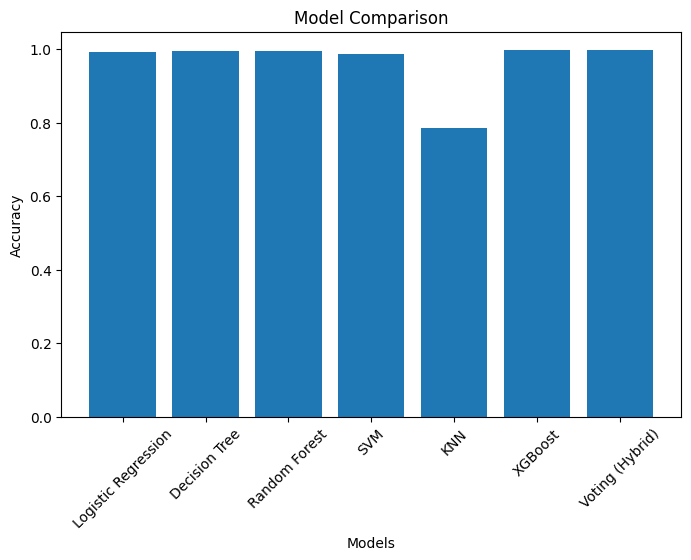

In [68]:
# Model comparison graph
plt.figure(figsize=(8,5))
plt.bar(results_df['Model'], results_df['Accuracy'])

plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Comparison")

plt.xticks(rotation=45)
plt.show()

In [57]:
best_model_name = results_df.loc[results_df['Accuracy'].idxmax(), 'Model']
print("\nBest Model:", best_model_name)

model = models[best_model_name]
model.fit(X_train, y_train)


Best Model: XGBoost


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:20:35] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [58]:
y_pred = model.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.9974

Confusion Matrix:
 [[ 5808    23     0]
 [   10 18287    15]
 [    0    30  5827]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      5831
           1       1.00      1.00      1.00     18312
           2       1.00      0.99      1.00      5857

    accuracy                           1.00     30000
   macro avg       1.00      1.00      1.00     30000
weighted avg       1.00      1.00      1.00     30000



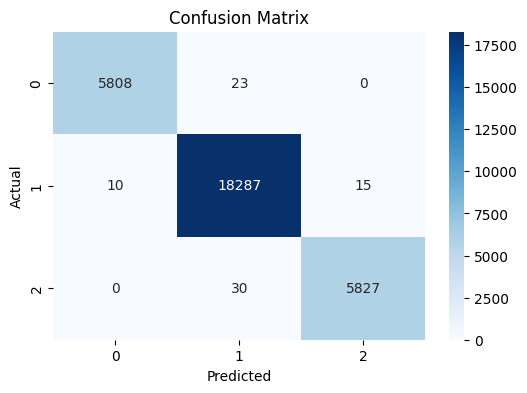

In [ ]:
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

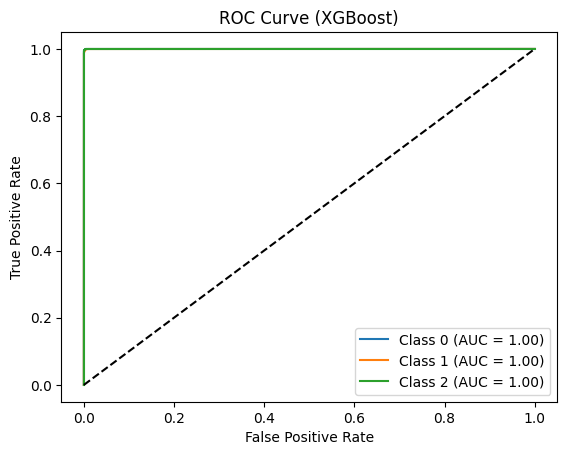

In [60]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Convert y_test into binary format
y_test_bin = label_binarize(y_test, classes=[0,1,2])
n_classes = y_test_bin.shape[1]

# Get probability predictions from XGBoost
y_score = model.predict_proba(X_test)

# Plot ROC curve
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (XGBoost)")
plt.legend()
plt.show()

In [ ]:
importances = model.feature_importances_
features = X.columns

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("\nTop Features:\n", importance_df.head(10))


Top Features:
                     Feature  Importance
18          lifestyle_score    0.639758
7              stress_level    0.352011
13  physical_activity_hours    0.000762
6         screen_time_hours    0.000748
5         daily_sleep_hours    0.000654
15    attendance_percentage    0.000565
9          depression_score    0.000499
11   financial_stress_score    0.000485
8             anxiety_score    0.000472
1                    gender    0.000465


In [61]:
import pickle

pickle.dump(model, open('model.pkl', 'wb'))
pickle.dump(scaler, open('scaler.pkl', 'wb'))
pickle.dump(X.columns, open('columns.pkl', 'wb'))

In [62]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 76.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 101.2 MB/s eta 0:00:00


In [63]:
%%writefile app.py

Writing app.py


In [69]:
import streamlit as st
import pandas as pd
import numpy as np
import pickle

model = pickle.load(open("model.pkl", "rb"))
scaler = pickle.load(open("scaler.pkl", "rb"))
columns = pickle.load(open("columns.pkl", "rb"))

st.title("Burnout Prediction System")

st.write("Enter student details to predict burnout level")

user_input = {}

for col in columns:

    if col == "gender":
        user_input[col] = st.selectbox("Gender", ["Male", "Female"])

    elif col == "course":
        user_input[col] = st.selectbox("Course", ["Science", "Commerce", "Arts"])

    else:
        user_input[col] = st.number_input(col, value=0)

if "gender" in user_input:
    if user_input["gender"] == "Male":
        user_input["gender"] = 1
    else:
        user_input["gender"] = 0

if "course" in user_input:
    course_map = {
        "Science": 0,
        "Commerce": 1,
        "Arts": 2
    }
    user_input["course"] = course_map[user_input["course"]]

input_df = pd.DataFrame([user_input])

input_df = input_df[columns]

input_scaled = scaler.transform(input_df)

if st.button("Predict Burnout"):

    input_scaled = scaler.transform(input_df)

    prediction = model.predict(input_scaled)[0]

    labels = ["Low Burnout", "Medium Burnout", "High Burnout"]

    st.subheader("Prediction Result")

    st.success(labels[int(prediction)])

2026-04-08 07:06:01.385 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 07:06:01.387 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 07:06:01.391 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 07:06:01.401 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 07:06:01.405 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 07:06:01.408 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 07:06:01.415 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 07:06:01.419 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [65]:
!pip install pyngrok

In [ ]:
!streamlit run app.py n




  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.106.200.60:8501

